In [1]:
from resources.imports import *

from resources.MLdata import DATA, load_data, UTprops, remove_outliers, save_MLdata, plot_sampling, get_stats,\
                             plot_frequency, plot_properties, plot_curve

In [2]:
### GLOBAL PATH INPUTS

DAT = DATA(path=0,
           path_add='',
           load=True,
           load_split=False,
           split_frac=0.8,
           save_split=False,
           LAT="FCC",
           nnx=12,
           nny=16,
           dis="disNodes",
           dN=0.2,
           mechMode="UT")

# Load Data

In [3]:
if DAT.load is not True:
    DAT.UT_INcsv  = DAT.PATH + f'Ductile-{DAT.dis}-IN.csv'
    DAT.UT_OUTcsv = DAT.PATH + f'Ductile-{DAT.dis}-OUT.csv'
    DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_INf_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_props_df = load_data(DAT.UT_INcsv, DAT.UT_OUTcsv)

# Prep Data

In [4]:
if DAT.load is not True:
    DAT.UT_props_r_df = UTprops(DAT.UT_OUT_df)
    DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_props_df, DAT.UT_INf_df = remove_outliers(DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_props_r_df, DAT.UT_INf_df)
    save_MLdata(DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_props_df, DAT.PATH, "UT", DAT.dis, DAT.UT_INf_df)

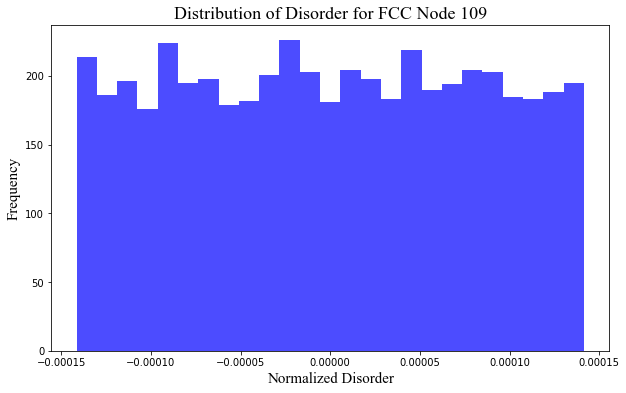

In [5]:
plot_sampling(DAT.UT_dIN_df, DAT.LAT, DAT.geom.l, indx=None, num=1, by="Node")

In [6]:
DAT.UT_stats, DAT.UT_nSims = get_stats(DAT.UT_props_df)
print("FINAL UT SIMULATION COUNT:", len(DAT.UT_OUT_df)-1)
print(f"{pd.concat([DAT.UT_stats, DAT.UT_nSims])}")
print("\n============================================================\n")
print(f"{(DAT.UT_props_df.loc[DAT.UT_nSims['Ductility'].loc['Max']]-DAT.UT_props_df.iloc[0])/DAT.UT_props_df.iloc[0]}\n\n")

FINAL UT SIMULATION COUNT: 4907
            Ductility     Strength    Stiffness          WoF
Mean         0.006161     9.296436  4269.586818     0.039150
Std          0.000698     0.171510    16.702884     0.003745
\%d Mean    -0.051629    -0.103891    -0.032482    -0.105958
\%d Std     -0.892517    -0.983468    -0.996215    -0.914481
Max       1415.000000  2843.000000  2037.000000   999.000000
Min       2240.000000  2727.000000  3251.000000  3149.000000


Ductility    0.268922
Strength    -0.108992
Stiffness   -0.038212
WoF          0.120014
dtype: float64




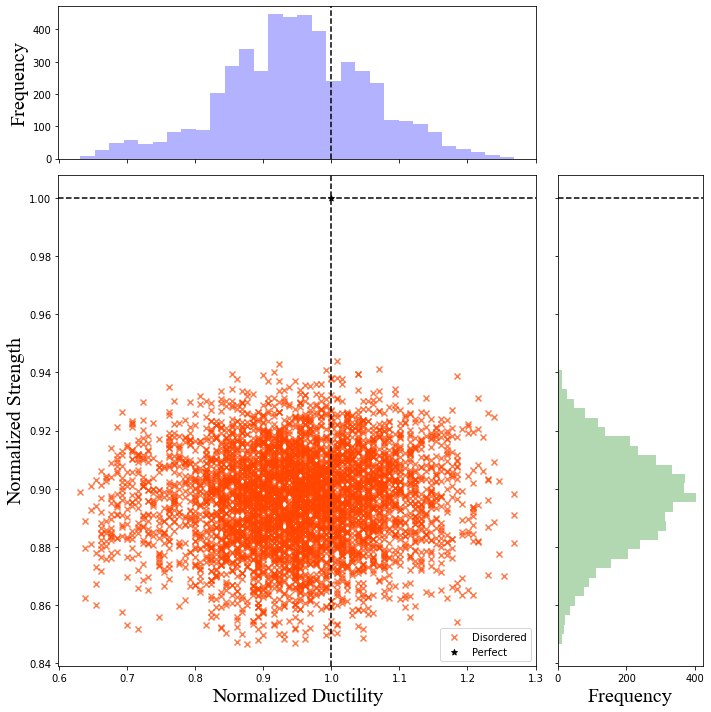

In [7]:
plot_allProps = True
plot_freq = True
plot_ONLY_freq = True

if plot_allProps:
    fig, ax = plot_properties(DAT.UT_props_df["Ductility"], DAT.UT_props_df["Strength"], "UT", include_freq=plot_freq, compare_ax=None, highlight=[DAT.common_nSims["Multi"].loc["Max"]] if DAT.mechMode.lower() == "multi" else None)

if plot_ONLY_freq and DAT.load is not True:
    plot_frequency(DAT.UT_props_r_df["Ductility"], DAT.UT_props_df["Ductility"], "UT", bins=30)

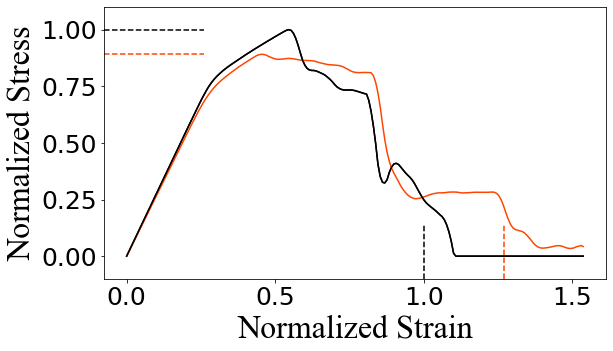

In [8]:
idx = None
q   = "all"
fig2, ax1 = plot_curve(DAT.UT_OUT_df, "ut", idx=[DAT.UT_nSims["Ductility"].loc["Max"]], q='all', compare_ax=None)